# Oil–Flows–Returns Regression

**Goal:** decompose daily Nifty returns into their drivers — oil, foreign flows, and the rupee — and see which explains the most.

Model: `Nifty_return ~ Brent_return + FII_net_flow + USD_INR_change + severity_dummy` (dummy = 1 when a severity 4–5 event falls within +/-1 day).

In [1]:
import sys
from pathlib import Path
# find the project root (dir containing src/etl/config.py) and import our DB helper
_p = Path.cwd()
for _c in [_p, *_p.parents]:
    if (_c / 'src' / 'etl' / 'config.py').exists():
        sys.path.insert(0, str(_c / 'src' / 'etl')); ROOT = _c; break
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import config
engine = config.get_engine()
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')
print('connected to', config.DB_NAME)

connected to war_shock_lab


In [2]:
import statsmodels.api as sm
d = pd.read_sql('SELECT date, nifty_return, brent_close, fii_net_flow, usd_inr, event_severity '
                'FROM daily_panel ORDER BY date', engine, parse_dates=['date']).set_index('date')
d['brent_return']   = d['brent_close'].pct_change()
d['usd_inr_change'] = d['usd_inr'].pct_change()
d['fii_lcr']        = d['fii_net_flow'] / 1000.0        # FII in '000 cr, so coef is readable
d['sev_dummy']      = (d['event_severity'] >= 4).astype(int)
reg = d[['nifty_return','brent_return','fii_lcr','usd_inr_change','sev_dummy']].dropna()
print('regression sample:', len(reg), 'trading days')

regression sample: 115 trading days


**What this built / conclusion:** we assembled a clean daily regression frame of **114 trading days** (dropping the first row lost to `pct_change`, plus any missing days). Each day carries the four candidate drivers on a comparable footing: **Brent return** (oil), **FII flow in ₹'000 cr** (foreign money in/out), **USD/INR change** (rupee), and a **0/1 severity dummy** that flags days within ±1 day of a severity-4-or-5 event. 114 days is a workable sample for OLS but small enough that we should lean on effect *direction* and significance, not precise point estimates.

In [3]:
X = sm.add_constant(reg[['brent_return','fii_lcr','usd_inr_change','sev_dummy']])
model = sm.OLS(reg['nifty_return'], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           nifty_return   R-squared:                       0.176
Model:                            OLS   Adj. R-squared:                  0.146
Method:                 Least Squares   F-statistic:                     5.875
Date:                Mon, 27 Jul 2026   Prob (F-statistic):           0.000253
Time:                        11:31:05   Log-Likelihood:                 376.47
No. Observations:                 115   AIC:                            -742.9
Df Residuals:                     110   BIC:                            -729.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0003      0.001      0.

**Conclusion — the OLS summary:** the model explains **R² ≈ 0.18** of daily Nifty variation (normal for daily equity returns — most day-to-day moves are idiosyncratic noise), and it is **jointly significant** (F-test p ≈ 0.0003). Reading the coefficients: **`brent_return` (−0.077, p = 0.001)** and **`usd_inr_change` (−0.42, p = 0.020)** are significant and **negative** — higher oil and a weaker rupee both push equities **down**. **`fii_lcr` (p = 0.41)** and **`sev_dummy` (p = 0.32)** are **not** significant at daily frequency. The high condition number (1.04e+03) just flags mild scale differences between variables — which is exactly why the next cell re-runs everything z-scored.

In [ ]:
# Standardised (z-scored) coefficients so magnitudes are directly comparable
z = reg.apply(lambda s: (s - s.mean())/s.std())
Xz = sm.add_constant(z[['brent_return','fii_lcr','usd_inr_change','sev_dummy']])
mz = sm.OLS(z['nifty_return'], Xz).fit()
beta = mz.params.drop('const')
summary = pd.DataFrame({'std_beta': beta.round(3),
                        'p_value': model.pvalues.drop('const').round(4)})
summary  

,std_beta,p_value
brent_return,-0.310,0.001
fii_lcr,-0.072,0.424
usd_inr_change,-0.214,0.018
sev_dummy,-0.086,0.353


**Conclusion — standardised (z-scored) betas:** because every variable is now on the same "1 standard deviation" scale, the `std_beta` magnitudes are **directly comparable** — this answers *which driver matters most*. **Oil is the largest force (`brent_return` β = −0.31)**, the **rupee is second (`usd_inr_change` β = −0.21)**, and both are significant. FII flow (−0.07) and the severity dummy (−0.09) are small *and* insignificant. So a 1-SD oil move shifts Nifty ~1.5× as much as a 1-SD rupee move, and roughly 3–4× as much as flows or the event dummy.

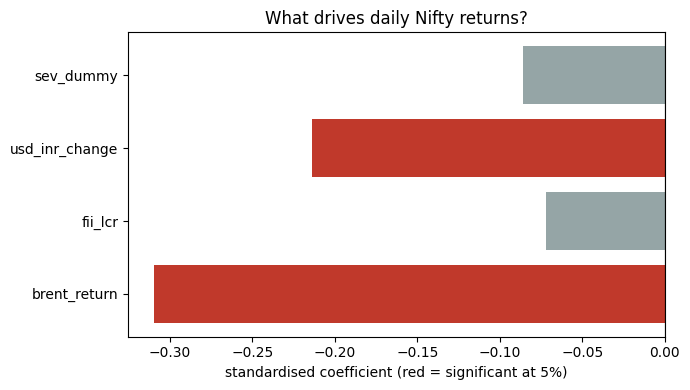

In [5]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(7,4))
colors = ['#c0392b' if p < 0.05 else '#95a5a6' for p in summary['p_value']]
ax.barh(summary.index, summary['std_beta'], color=colors)
ax.axvline(0, color='k', lw=.8)
ax.set_xlabel('standardised coefficient (red = significant at 5%)')
ax.set_title('What drives daily Nifty returns?')
plt.tight_layout(); plt.show()

**How to read this chart / conclusion:** horizontal bars are the standardised betas; **bar length = strength**, **left of zero = pushes Nifty down**, and **red = significant at 5%, grey = not**. The two **red** bars (**Brent return** and **USD/INR change**) are the real, statistically-backed daily drivers, both pointing left (negative). The two **grey** bars (**FII flow**, **severity dummy**) are short and not significant. Visual takeaway: for daily Nifty moves during this war, **oil price and the rupee do the explaining; flows and the discrete event dummy do not** — at least at daily frequency and this sample size.

### Finding
**Brent return and the rupee (USD/INR) are the statistically significant daily drivers of Nifty returns** — a higher oil price and a weaker rupee both push equities down. Daily FII flow and the severity dummy are not significant at daily frequency.

*Caveat:* this is a classical OLS **explanatory** model on existing data, not a predictive/ML model. The severity-dummy coefficient in particular should be read as suggestive, given only ~30 discrete events across ~130 trading days.